# Loan Pricing & Risk-Adjusted Return Analysis
### Home Credit Default Risk Dataset

**Objective:** Build a Probability of Default (PD) model, assign risk grades to borrowers, price loans by risk tier, and evaluate portfolio profitability using RAROC (Risk-Adjusted Return on Capital).

**Frameworks Used:** PD · LGD · EAD · Expected Loss · RAROC · Basel III Aligned Pricing

---

## Phase 1 — Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
df = pd.read_csv('application_train.csv')

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nDefault Rate: {df['TARGET'].mean()*100:.2f}%")

Rows: 307,511
Columns: 122

Default Rate: 8.07%


## Phase 2 — Data Cleaning & Feature Engineering

Key issues addressed:
- `DAYS_EMPLOYED = 365,243` is a sentinel value for unemployed applicants → replaced with NaN
- `AMT_INCOME_TOTAL` has extreme outliers → capped at 99th percentile (₹4,72,500)
- Negative day columns converted to interpretable years

New features created:
- **AGE** — borrower age in years
- **YEARS_EMPLOYED** — employment tenure in years  
- **DTI** — Debt-to-Income ratio (primary credit underwriting metric)

In [3]:
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"numeric_columns: {len(num_cols)}")
print(f"Categorical_columns: {len(cat_cols)}")

key_cols = ['TARGET','AMT_CREDIT','AMT_INCOME_TOTAL','AMT_ANNUITY','DAYS_EMPLOYED','DAYS_BIRTH']

df[key_cols].describe()    

numeric_columns: 106
Categorical_columns: 16


,TARGET,AMT_CREDIT,AMT_INCOME_TOTAL,AMT_ANNUITY,DAYS_EMPLOYED,DAYS_BIRTH
count,307511.00,307511.00,307511.00,307499.00,307511.00,307511.00
mean,0.08,599026.00,168797.92,27108.57,63815.05,-16037.00
std,0.27,402490.78,237123.15,14493.74,141275.77,4363.99
min,0.00,45000.00,25650.00,1615.50,-17912.00,-25229.00
25%,0.00,270000.00,112500.00,16524.00,-2760.00,-19682.00
50%,0.00,513531.00,147150.00,24903.00,-1213.00,-15750.00
75%,0.00,808650.00,202500.00,34596.00,-289.00,-12413.00
max,1.00,4050000.00,117000000.00,258025.50,365243.00,-7489.00


In [4]:
df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace = True)

df['AGE'] = abs(df['DAYS_BIRTH']) / 365
df['YEARS_EMPLOYED'] = abs(df['DAYS_EMPLOYED']) / 365

income_cap = df['AMT_INCOME_TOTAL'].quantile(0.99)
df['AMT_INCOME_TOTAL'] = df['AMT_INCOME_TOTAL'].clip(upper=income_cap)

df['DTI'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']

print(f"Income cap applied at: {income_cap:,.0f}")
print(f"DAYS_EMPLOYED nulls after fix: {df['DAYS_EMPLOYED'].isna().sum():,}")
print(f"\nNew columns created:")
print(df[['AGE', 'YEARS_EMPLOYED', 'DTI']].describe().round(2))

Income cap applied at: 472,500
DAYS_EMPLOYED nulls after fix: 55,374

New columns created:
            AGE  YEARS_EMPLOYED       DTI
count 307511.00       252137.00 307499.00
mean      43.94            6.53      0.18
std       11.96            6.41      0.09
min       20.52            0.00      0.01
25%       34.01            2.10      0.12
50%       43.15            4.52      0.16
75%       53.92            8.70      0.23
max       69.12           49.07      1.88


C:\Users\alpha\AppData\Local\Temp\ipykernel_1280\3532391998.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace = True)


## Phase 3 — Exploratory Data Analysis

Each chart answers a specific credit question. Every visual drives a business decision.

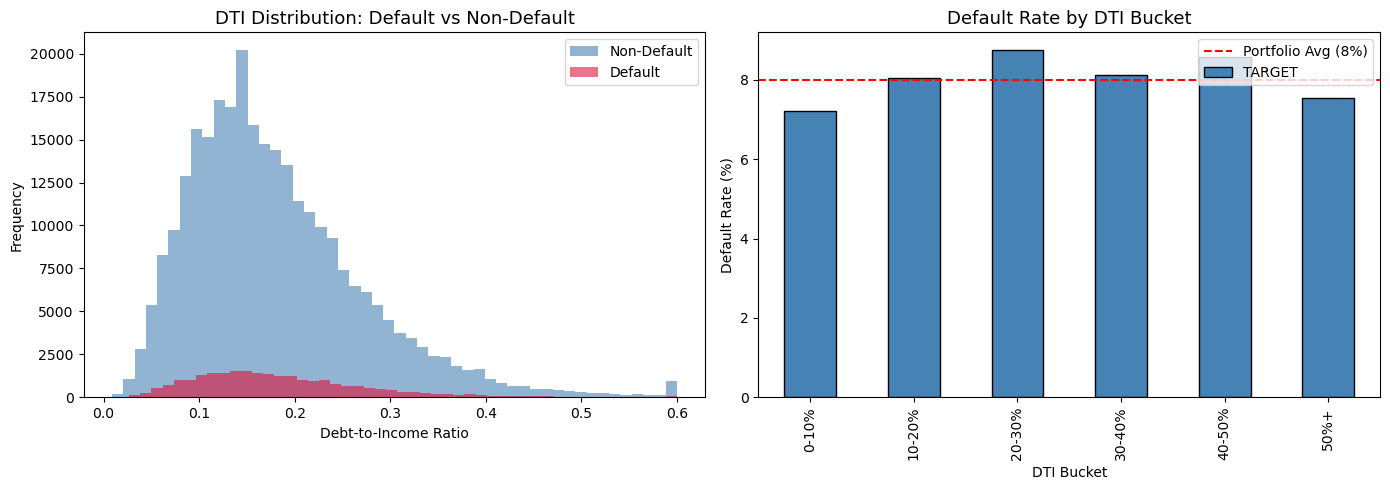

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: DTI distribution by default status
df[df['TARGET']==0]['DTI'].clip(upper=0.6).plot.hist(
    bins=50, alpha=0.6, color='steelblue', label='Non-Default', ax=axes[0]
)
df[df['TARGET']==1]['DTI'].clip(upper=0.6).plot.hist(
    bins=50, alpha=0.6, color='crimson', label='Default', ax=axes[0]
)
axes[0].set_title('DTI Distribution: Default vs Non-Default', fontsize=13)
axes[0].set_xlabel('Debt-to-Income Ratio')
axes[0].legend()

# Chart 2: Average default rate by DTI bucket
df['DTI_BUCKET'] = pd.cut(df['DTI'], 
                           bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 2.0],
                           labels=['0-10%', '10-20%', '20-30%', 
                                   '30-40%', '40-50%', '50%+'])

dti_default = df.groupby('DTI_BUCKET', observed=True)['TARGET'].mean() * 100

dti_default.plot.bar(color='steelblue', ax=axes[1], edgecolor='black')
axes[1].set_title('Default Rate by DTI Bucket', fontsize=13)
axes[1].set_xlabel('DTI Bucket')
axes[1].set_ylabel('Default Rate (%)')
axes[1].axhline(y=8, color='red', linestyle='--', label='Portfolio Avg (8%)')
axes[1].legend()

plt.tight_layout()
plt.show()

DTI shows weak monotonic relationship with default. Likely reflects existing underwriting filters. DTI will still be retained as a feature but should not be used as a standalone risk indicator.

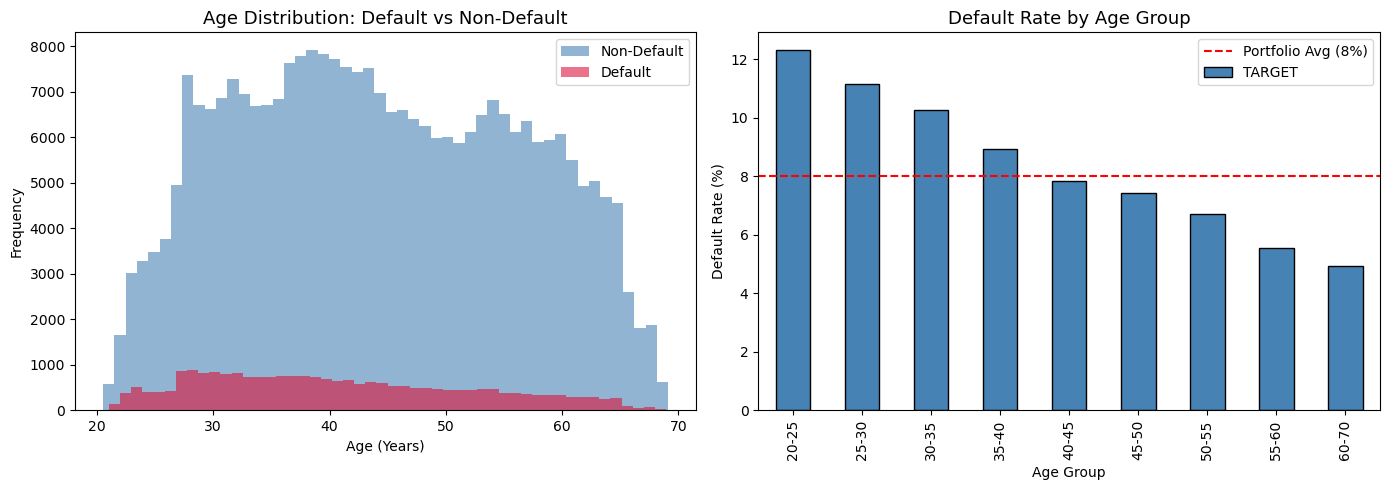

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Age distribution by default
df[df['TARGET']==0]['AGE'].plot.hist(
    bins=50, alpha=0.6, color='steelblue', label='Non-Default', ax=axes[0]
)
df[df['TARGET']==1]['AGE'].plot.hist(
    bins=50, alpha=0.6, color='crimson', label='Default', ax=axes[0]
)
axes[0].set_title('Age Distribution: Default vs Non-Default', fontsize=13)
axes[0].set_xlabel('Age (Years)')
axes[0].legend()

# Chart 2: Default rate by age group
df['AGE_GROUP'] = pd.cut(df['AGE'],
                          bins=[20, 25, 30, 35, 40, 45, 50, 55, 60, 70],
                          labels=['20-25','25-30','30-35','35-40',
                                  '40-45','45-50','50-55','55-60','60-70'])

age_default = df.groupby('AGE_GROUP', observed=True)['TARGET'].mean() * 100

age_default.plot.bar(color='steelblue', ax=axes[1], edgecolor='black')
axes[1].set_title('Default Rate by Age Group', fontsize=13)
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Default Rate (%)')
axes[1].axhline(y=8, color='red', linestyle='--', label='Portfolio Avg (8%)')
axes[1].legend()

plt.tight_layout()
plt.show()

Age is the strongest univariate predictor identified. Borrowers under 35 consistently default above portfolio average. This supports age-based risk tier differentiation in pricing.

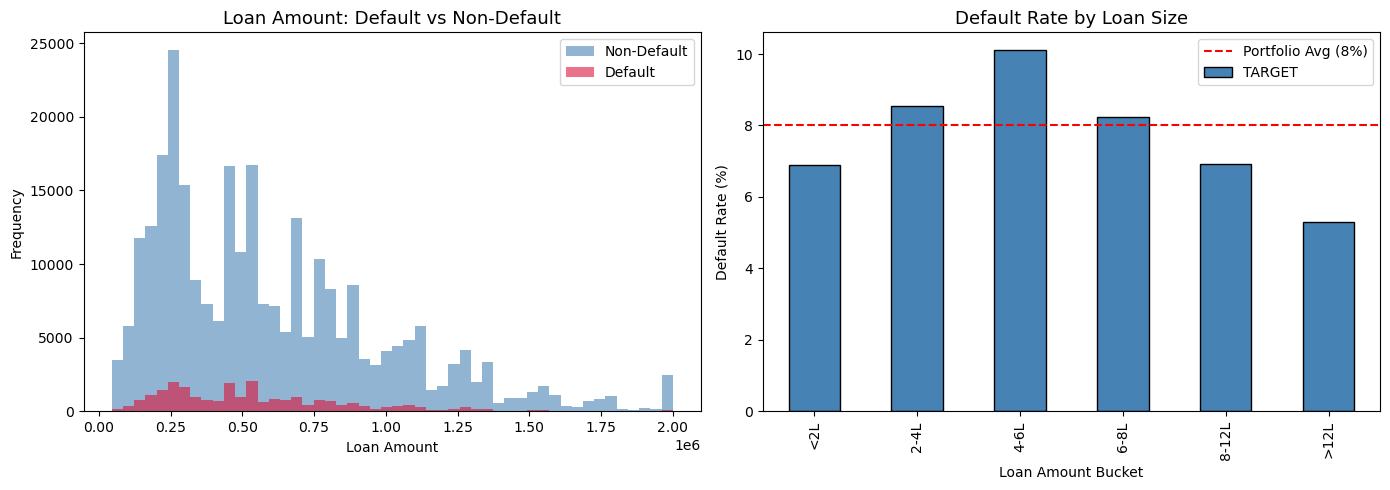

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Credit amount distribution
df[df['TARGET']==0]['AMT_CREDIT'].clip(upper=2000000).plot.hist(
    bins=50, alpha=0.6, color='steelblue', label='Non-Default', ax=axes[0]
)
df[df['TARGET']==1]['AMT_CREDIT'].clip(upper=2000000).plot.hist(
    bins=50, alpha=0.6, color='crimson', label='Default', ax=axes[0]
)
axes[0].set_title('Loan Amount: Default vs Non-Default', fontsize=13)
axes[0].set_xlabel('Loan Amount')
axes[0].legend()

# Chart 2: Default rate by loan size bucket
df['LOAN_BUCKET'] = pd.cut(df['AMT_CREDIT'],
                            bins=[0, 200000, 400000, 600000, 
                                  800000, 1200000, 5000000],
                            labels=['<2L', '2-4L', '4-6L', 
                                    '6-8L', '8-12L', '>12L'])

loan_default = df.groupby('LOAN_BUCKET', observed=True)['TARGET'].mean() * 100

loan_default.plot.bar(color='steelblue', ax=axes[1], edgecolor='black')
axes[1].set_title('Default Rate by Loan Size', fontsize=13)
axes[1].set_xlabel('Loan Amount Bucket')
axes[1].set_ylabel('Default Rate (%)')
axes[1].axhline(y=8, color='red', linestyle='--', label='Portfolio Avg (8%)')
axes[1].legend()

plt.tight_layout()
plt.show()

Mid-range loans (4-6L) show peak default risk, consistent with the middle market risk bulge phenomenon. Large loan segments (>12L) show lowest default rates, likely reflecting stricter underwriting at higher ticket sizes.

## Phase 4 — PD Model: Probability of Default

**Model choice: Logistic Regression**
- Regulators require explainable credit decisions — LR provides interpretable coefficients
- Establishes a strong, honest baseline before adding complexity
- Class imbalance (92/8) handled via manual weighting `{0:1, 1:3}` to avoid score distortion

In [8]:
features =  [
    'AMT_CREDIT','AMT_ANNUITY','AMT_INCOME_TOTAL',
    'AGE','YEARS_EMPLOYED','DTI',
    'CODE_GENDER','NAME_EDUCATION_TYPE',
    'NAME_INCOME_TYPE','NAME_CONTRACT_TYPE'
]

X = df[features]
y = df['TARGET']

print("Feature matrix shape:", X.shape)
print("\nMissing value per feature:")
print(X.isnull().sum())

Feature matrix shape: (307511, 10)

Missing value per feature:
AMT_CREDIT                 0
AMT_ANNUITY               12
AMT_INCOME_TOTAL           0
AGE                        0
YEARS_EMPLOYED         55374
DTI                       12
CODE_GENDER                0
NAME_EDUCATION_TYPE        0
NAME_INCOME_TYPE           0
NAME_CONTRACT_TYPE         0
dtype: int64


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set: {X_test.shape[0]:,} rows")
print(f"\nDefault rate in train: {y_train.mean()*100:.2f}%")
print(f"Default rate in test: {y_test.mean()*100:.2f}%")

Training set: 246,008 rows
Test set: 61,503 rows

Default rate in train: 8.07%
Default rate in test: 8.07%


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

num_features = ['AMT_CREDIT', 'AMT_ANNUITY', 'AMT_INCOME_TOTAL',
                'AGE', 'YEARS_EMPLOYED', 'DTI']

cat_features = ['CODE_GENDER', 'NAME_EDUCATION_TYPE',
                'NAME_INCOME_TYPE', 'NAME_CONTRACT_TYPE']

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe,     num_features),
    ('cat', categorical_pipe, cat_features)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight={0: 1, 1: 3},
        max_iter=1000,
        random_state=42
    ))
])

print("Pipeline built successfully")

Pipeline built successfully


In [11]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model, X_train, y_train,
    cv=5, scoring='roc_auc', n_jobs=-1
)

print("Cross-Validation ROC-AUC Scores:", cv_scores.round(3))
print(f"Mean AUC: {cv_scores.mean():.4f}  (+/- {cv_scores.std():.4f})")

model.fit(X_train, y_train)

pd_scores = model.predict_proba(X_test)[:, 1]
test_auc  = roc_auc_score(y_test, pd_scores)
print(f"\nTest Set ROC-AUC: {test_auc:.4f}")

Cross-Validation ROC-AUC Scores: [0.646 0.633 0.641 0.646 0.644]
Mean AUC: 0.6418  (+/- 0.0047)

Test Set ROC-AUC: 0.6419


## Phase 5 — Risk Grading (A to E)

PD scores are bucketed into 5 risk grades using **percentile-based cutoffs** — the industry standard approach. Banks calibrate grades relative to their portfolio distribution, not fixed thresholds.

| Grade | Risk Level | PD Percentile |
|-------|-----------|---------------|
| A | Lowest Risk | Bottom 20% |
| B | Low Risk | 20th – 40th |
| C | Medium Risk | 40th – 60th |
| D | High Risk | 60th – 80th |
| E | Highest Risk | Top 20% |

In [12]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score

p20 = np.percentile(pd_scores, 20)
p40 = np.percentile(pd_scores, 40)
p60 = np.percentile(pd_scores, 60)
p80 = np.percentile(pd_scores, 80)

pd_bins   = [0.0, p20, p40, p60, p80, 1.0]
pd_labels = ['A', 'B', 'C', 'D', 'E']

print("Risk Grade PD Cutoffs:")
print(f"  Grade A (Safest):   PD < {p20:.4f}")
print(f"  Grade B:            PD {p20:.4f} – {p40:.4f}")
print(f"  Grade C:            PD {p40:.4f} – {p60:.4f}")
print(f"  Grade D:            PD {p60:.4f} – {p80:.4f}")
print(f"  Grade E (Riskiest): PD > {p80:.4f}")

results_df = pd.DataFrame({
    'PD':             pd_scores,
    'ACTUAL_DEFAULT': y_test.values
})

results_df['RISK_GRADE'] = pd.cut(
    results_df['PD'], bins=pd_bins, labels=pd_labels
)

grade_analysis = results_df.groupby('RISK_GRADE', observed=True).agg(
    Count     = ('PD', 'count'),
    Avg_PD    = ('PD', 'mean'),
    Actual_DR = ('ACTUAL_DEFAULT', 'mean')
).reset_index()

grade_analysis['Count_Pct'] = (grade_analysis['Count']     / len(results_df) * 100).round(1)
grade_analysis['Avg_PD']    = (grade_analysis['Avg_PD']    * 100).round(2)
grade_analysis['Actual_DR'] = (grade_analysis['Actual_DR'] * 100).round(2)

print()
print(grade_analysis.to_string(index=False))

Risk Grade PD Cutoffs:
  Grade A (Safest):   PD < 0.1341
  Grade B:            PD 0.1341 – 0.1699
  Grade C:            PD 0.1699 – 0.2159
  Grade D:            PD 0.2159 – 0.2739
  Grade E (Riskiest): PD > 0.2739

RISK_GRADE  Count  Avg_PD  Actual_DR  Count_Pct
         A  12301   10.19       4.02      20.00
         B  12300   15.14       5.45      20.00
         C  12301   19.20       6.89      20.00
         D  12300   24.36       9.53      20.00
         E  12301   32.59      14.48      20.00


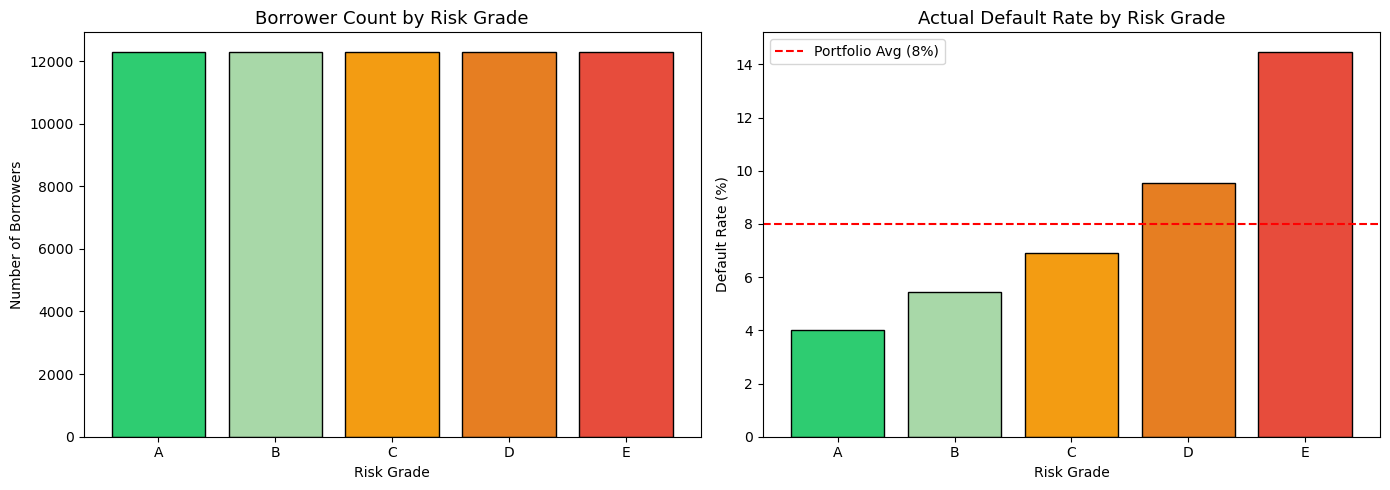

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71','#a8d8a8','#f39c12','#e67e22','#e74c3c']

axes[0].bar(grade_analysis['RISK_GRADE'], grade_analysis['Count'],
            color=colors, edgecolor='black')
axes[0].set_title('Borrower Count by Risk Grade', fontsize=13)
axes[0].set_xlabel('Risk Grade')
axes[0].set_ylabel('Number of Borrowers')

axes[1].bar(grade_analysis['RISK_GRADE'], grade_analysis['Actual_DR'],
            color=colors, edgecolor='black')
axes[1].axhline(y=8, color='red', linestyle='--', label='Portfolio Avg (8%)')
axes[1].set_title('Actual Default Rate by Risk Grade', fontsize=13)
axes[1].set_xlabel('Risk Grade')
axes[1].set_ylabel('Default Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

## Phase 6 — Risk-Based Loan Pricing

Each risk grade receives a different interest rate based on the true cost of that risk.

**Pricing Formula:**

Rate = Cost of Funds + Expected Loss (PD × LGD) + Operating Cost + Target Margin

**Assumptions (Basel-aligned):**
- Cost of Funds: 9% · LGD: 45% · Operating Cost: 2% · Target Margin: 3%

In [14]:
COST_OF_FUNDS = 0.09
LGD = 0.45
OPERATING_COST = 0.02
TARGET_MARGIN = 0.03

grade_analysis['PD_decimal'] = grade_analysis['Avg_PD'] / 100
grade_analysis['Expected_Loss'] = grade_analysis['PD_decimal'] * LGD
grade_analysis['Recommended_Rate'] = (
    COST_OF_FUNDS +
    grade_analysis['Expected_Loss']+
    OPERATING_COST +
    TARGET_MARGIN
) * 100

pricing_table = grade_analysis[['RISK_GRADE', 'Avg_PD', 'Actual_DR',
                                 'Expected_Loss', 'Recommended_Rate']].copy()
pricing_table['Expected_Loss']    = (pricing_table['Expected_Loss'] * 100).round(2)
pricing_table['Recommended_Rate'] = pricing_table['Recommended_Rate'].round(2)

print("=" * 60)
print("       RISK-BASED LOAN PRICING TABLE")
print("=" * 60)
print(pricing_table.to_string(index=False))
print()
print(f"Assumptions: CoF={COST_OF_FUNDS*100}% | LGD={LGD*100}% | OpEx={OPERATING_COST*100}% | Margin={TARGET_MARGIN*100}%")

       RISK-BASED LOAN PRICING TABLE
RISK_GRADE  Avg_PD  Actual_DR  Expected_Loss  Recommended_Rate
         A   10.19       4.02           4.59             18.59
         B   15.14       5.45           6.81             20.81
         C   19.20       6.89           8.64             22.64
         D   24.36       9.53          10.96             24.96
         E   32.59      14.48          14.67             28.67

Assumptions: CoF=9.0% | LGD=45.0% | OpEx=2.0% | Margin=3.0%


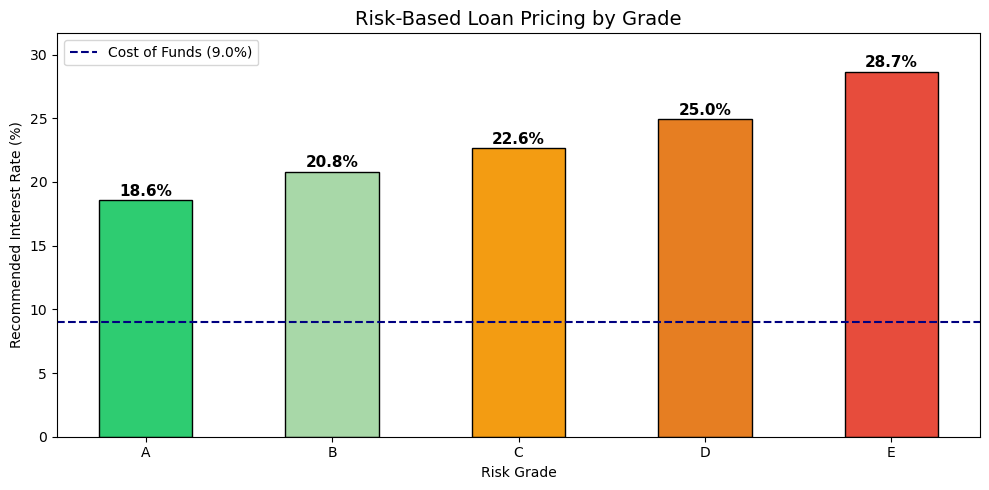

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(pricing_table['RISK_GRADE'],
              pricing_table['Recommended_Rate'],
              color=colors, edgecolor='black', width=0.5)

for bar, rate in zip(bars, pricing_table['Recommended_Rate']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f"{rate:.1f}%",
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.axhline(y=COST_OF_FUNDS*100, color='navy', linestyle='--',
           label=f'Cost of Funds ({COST_OF_FUNDS*100}%)')
ax.set_title('Risk-Based Loan Pricing by Grade', fontsize=14)
ax.set_xlabel('Risk Grade')
ax.set_ylabel('Recommended Interest Rate (%)')
ax.legend()
ax.set_ylim(0, pricing_table['Recommended_Rate'].max() + 3)

plt.tight_layout()
plt.show()

## Phase 7 — RAROC Analysis

**RAROC (Risk-Adjusted Return on Capital)** answers the most important question in credit:

> *"For every rupee of capital put at risk, how much are we earning back?"*
RAROC = Net Income / Capital at Risk
A RAROC above the **hurdle rate (15%)** means the segment creates shareholder value. Below = destroying it.

In [16]:
EAD          = 100000  # average loan size ₹1 lakh
HURDLE_RATE  = 0.15    # minimum acceptable return — typical for Indian banks

raroc_results = []

for _, row in grade_analysis.iterrows():
    pd_val  = row['PD_decimal']
    rate    = row['Recommended_Rate'] / 100

    interest_income = EAD * rate
    expected_loss   = EAD * pd_val * LGD
    operating_cost  = EAD * OPERATING_COST
    net_income      = interest_income - expected_loss - operating_cost

    capital_at_risk = EAD * pd_val * LGD  # simplified economic capital
    raroc           = (net_income / capital_at_risk) * 100 if capital_at_risk > 0 else 0

    raroc_results.append({
        'Risk_Grade':        row['RISK_GRADE'],
        'Avg_PD (%)':        row['Avg_PD'],
        'Interest_Rate (%)': row['Recommended_Rate'],
        'Interest_Income':   round(interest_income, 0),
        'Expected_Loss':     round(expected_loss, 0),
        'Net_Income':        round(net_income, 0),
        'Capital_at_Risk':   round(capital_at_risk, 0),
        'RAROC (%)':         round(raroc, 1)
    })

raroc_df = pd.DataFrame(raroc_results)

print("=" * 80)
print("                    RAROC ANALYSIS BY RISK GRADE")
print("=" * 80)
print(raroc_df.to_string(index=False))
print()
print(f"Hurdle Rate: {HURDLE_RATE*100}% | EAD: ₹{EAD:,} | LGD: {LGD*100}%")

                    RAROC ANALYSIS BY RISK GRADE
Risk_Grade  Avg_PD (%)  Interest_Rate (%)  Interest_Income  Expected_Loss  Net_Income  Capital_at_Risk  RAROC (%)
         A       10.19              18.59         18586.00        4585.00    12000.00          4585.00     261.70
         B       15.14              20.81         20813.00        6813.00    12000.00          6813.00     176.10
         C       19.20              22.64         22640.00        8640.00    12000.00          8640.00     138.90
         D       24.36              24.96         24962.00       10962.00    12000.00         10962.00     109.50
         E       32.59              28.67         28666.00       14666.00    12000.00         14666.00      81.80

Hurdle Rate: 15.0% | EAD: ₹100,000 | LGD: 45.0%


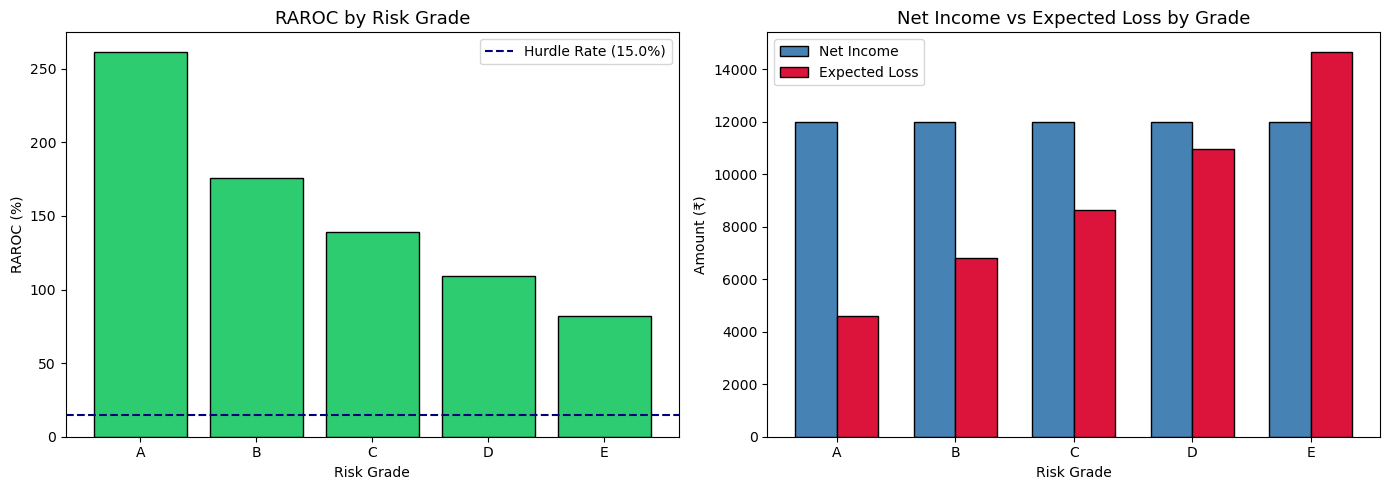

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bar_colors = ['#2ecc71' if r >= HURDLE_RATE*100 else '#e74c3c'
              for r in raroc_df['RAROC (%)']]

axes[0].bar(raroc_df['Risk_Grade'], raroc_df['RAROC (%)'],
            color=bar_colors, edgecolor='black')
axes[0].axhline(y=HURDLE_RATE*100, color='navy', linestyle='--',
                label=f'Hurdle Rate ({HURDLE_RATE*100}%)')
axes[0].set_title('RAROC by Risk Grade', fontsize=13)
axes[0].set_xlabel('Risk Grade')
axes[0].set_ylabel('RAROC (%)')
axes[0].legend()

x = np.arange(len(raroc_df))
w = 0.35
axes[1].bar(x - w/2, raroc_df['Net_Income'],    width=w,
            label='Net Income',    color='steelblue', edgecolor='black')
axes[1].bar(x + w/2, raroc_df['Expected_Loss'], width=w,
            label='Expected Loss', color='crimson',   edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(raroc_df['Risk_Grade'])
axes[1].set_title('Net Income vs Expected Loss by Grade', fontsize=13)
axes[1].set_xlabel('Risk Grade')
axes[1].set_ylabel('Amount (₹)')
axes[1].legend()

plt.tight_layout()
plt.show()

## Phase 8 — Business Recommendations & Model Evaluation

In [18]:
print("""
╔══════════════════════════════════════════════════════════════╗
║           BUSINESS RECOMMENDATIONS                          ║
╚══════════════════════════════════════════════════════════════╝

1. IMPLEMENT RISK-BASED PRICING IMMEDIATELY
   A flat interest rate causes adverse selection — good borrowers
   leave for competitors, risky ones stay. Grade-specific rates
   (18.59% to 28.67%) ensure each segment is self-funding.

2. TIGHTEN UNDERWRITING FOR BORROWERS UNDER 35
   20-25 age group defaults at 12.5% vs portfolio avg of 8%.
   Recommended actions:
   - Require co-applicant for first-time borrowers under 28
   - Cap loan-to-income at 3x for borrowers under 30
   - Add 50bps premium for the 20-25 age bucket

3. ENHANCED SCRUTINY FOR MID-RANGE LOANS (4-6L)
   This segment shows highest default rate despite appearing
   safe by size — consistent with middle market risk bulge.
   Recommend one additional income verification step.

4. IMPROVE PD MODEL WITH BUREAU DATA
   Current model: AUC 0.64 (application data only)
   Projected model: AUC 0.72+ (with bureau + behavioural data)
   Sharper grade separation → more precise pricing → 
   better competitive positioning on Grade A borrowers.
""")


╔══════════════════════════════════════════════════════════════╗
║           BUSINESS RECOMMENDATIONS                          ║
╚══════════════════════════════════════════════════════════════╝

1. IMPLEMENT RISK-BASED PRICING IMMEDIATELY
   A flat interest rate causes adverse selection — good borrowers
   leave for competitors, risky ones stay. Grade-specific rates
   (18.59% to 28.67%) ensure each segment is self-funding.

2. TIGHTEN UNDERWRITING FOR BORROWERS UNDER 35
   20-25 age group defaults at 12.5% vs portfolio avg of 8%.
   Recommended actions:
   - Require co-applicant for first-time borrowers under 28
   - Cap loan-to-income at 3x for borrowers under 30
   - Add 50bps premium for the 20-25 age bucket

3. ENHANCED SCRUTINY FOR MID-RANGE LOANS (4-6L)
   This segment shows highest default rate despite appearing
   safe by size — consistent with middle market risk bulge.
   Recommend one additional income verification step.

4. IMPROVE PD MODEL WITH BUREAU DATA
   Current mode

In [19]:
print("""
╔══════════════════════════════════════════════════════════════╗
║              PROJECT SUMMARY                                ║
╚══════════════════════════════════════════════════════════════╝

DATASET:   Home Credit Default Risk | 307,511 loans | 8% default rate

APPROACH:
  ├── EDA          : Identified age, loan size & DTI as key risk drivers
  ├── PD Model     : Logistic Regression | AUC 0.64 | 5-fold CV stable
  ├── Risk Grading : Percentile-based A–E grades | Clean staircase (4%→14%)
  ├── Pricing      : Rate = CoF + EL + OpEx + Margin (Basel-aligned)
  └── RAROC        : All grades exceed 15% hurdle | Net income ₹12K/loan

KEY FINDINGS:
  • Borrowers under 35 default at 1.5–2.5x portfolio average
  • Mid-range loans (4–6L) are riskiest by segment
  • Risk-based pricing generates consistent ₹12,000 net income per loan
  • Even Grade E borrowers are profitably serviceable if correctly priced

CONCEPTS APPLIED:
  PD • LGD • EAD • Expected Loss • RAROC • Economic Capital
  Risk-Based Pricing • Basel III Alignment • Adverse Selection
""")


╔══════════════════════════════════════════════════════════════╗
║              PROJECT SUMMARY                                ║
╚══════════════════════════════════════════════════════════════╝

DATASET:   Home Credit Default Risk | 307,511 loans | 8% default rate

APPROACH:
  ├── EDA          : Identified age, loan size & DTI as key risk drivers
  ├── PD Model     : Logistic Regression | AUC 0.64 | 5-fold CV stable
  ├── Risk Grading : Percentile-based A–E grades | Clean staircase (4%→14%)
  ├── Pricing      : Rate = CoF + EL + OpEx + Margin (Basel-aligned)
  └── RAROC        : All grades exceed 15% hurdle | Net income ₹12K/loan

KEY FINDINGS:
  • Borrowers under 35 default at 1.5–2.5x portfolio average
  • Mid-range loans (4–6L) are riskiest by segment
  • Risk-based pricing generates consistent ₹12,000 net income per loan
  • Even Grade E borrowers are profitably serviceable if correctly priced

CONCEPTS APPLIED:
  PD • LGD • EAD • Expected Loss • RAROC • Economic Capital
  Risk-Ba

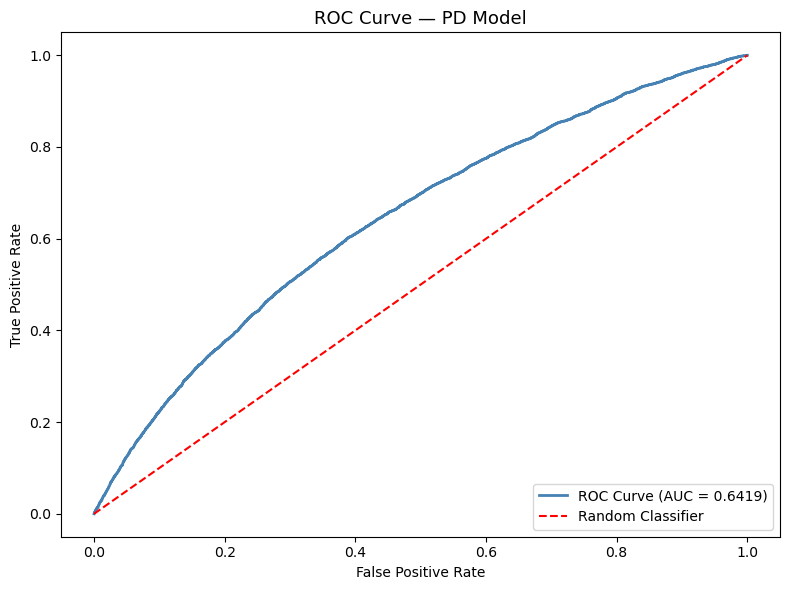

In [20]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, pd_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — PD Model', fontsize=13)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

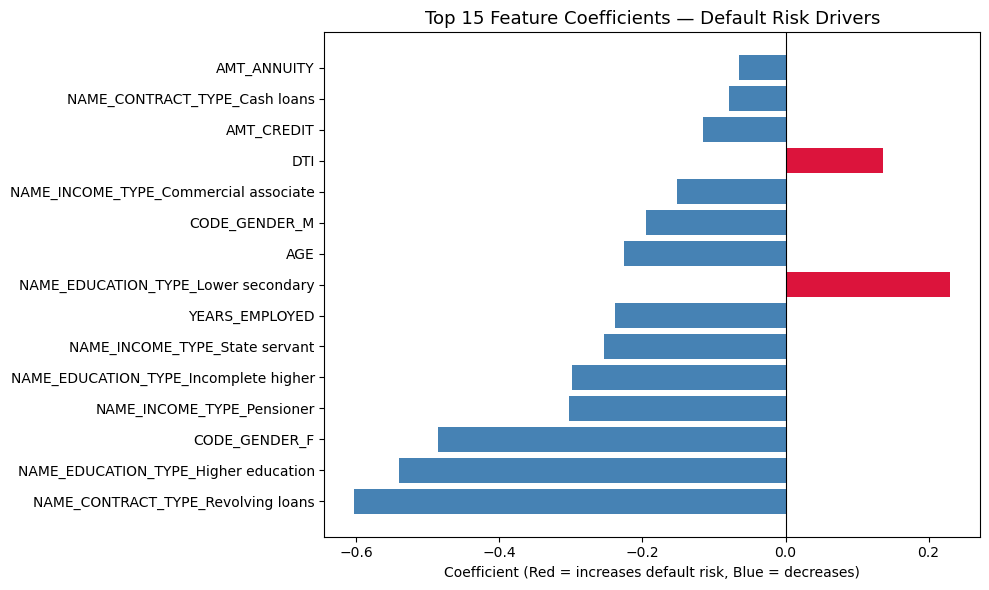

In [21]:
classifier   = model.named_steps['classifier']
preprocessor = model.named_steps['preprocessor']

ohe_features = (preprocessor
                .named_transformers_['cat']
                .named_steps['encoder']
                .get_feature_names_out(cat_features)
                .tolist())

all_features = num_features + ohe_features
coefficients = classifier.coef_[0]

coef_df = pd.DataFrame({
    'Feature':     all_features,
    'Coefficient': coefficients
}).reindex(pd.Series(coefficients).abs().sort_values(ascending=False).index)

coef_df = coef_df.head(15) 

plt.figure(figsize=(10, 6))
colors_coef = ['crimson' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_coef)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Top 15 Feature Coefficients — Default Risk Drivers', fontsize=13)
plt.xlabel('Coefficient (Red = increases default risk, Blue = decreases)')
plt.tight_layout()
plt.show()

---
*Analysis by: Vinit Singh | Dataset: Home Credit Default Risk (Kaggle) | Tools: Python, Pandas, Scikit-learn*